In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import climattr as eea

plt.rcParams.update({'font.size': 14})

/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_25554/3292979026.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  obs_temp = obs_temp.groupby('region').apply(lambda x: (x['mean_2m_air_temp_degree1'] * x['population']).sum() / x['population'].sum())


North
-53.717499994659626 -52.984805967671704 -52.31393744246642
-53.18726781376262 -52.98885393903243 -52.810781373092105
Northeast
-24.212461036717556 -23.83051113132018 -23.468136363799804
-23.882397504283436 -23.833473891198587 -23.79085640057095
Middle-West
32.34282961827796 33.211386220177225 34.078298302284914
33.4593725462324 33.21410052612643 33.01671673176069
Southeast
37.123177036709826 38.27014974087094 39.35137517153385
38.169568544693895 38.25945786207029 38.37555459092668
South
40.254510078754265 41.65443696501411 43.08246934216898
41.72941434705631 41.666328488460415 41.61196352940662


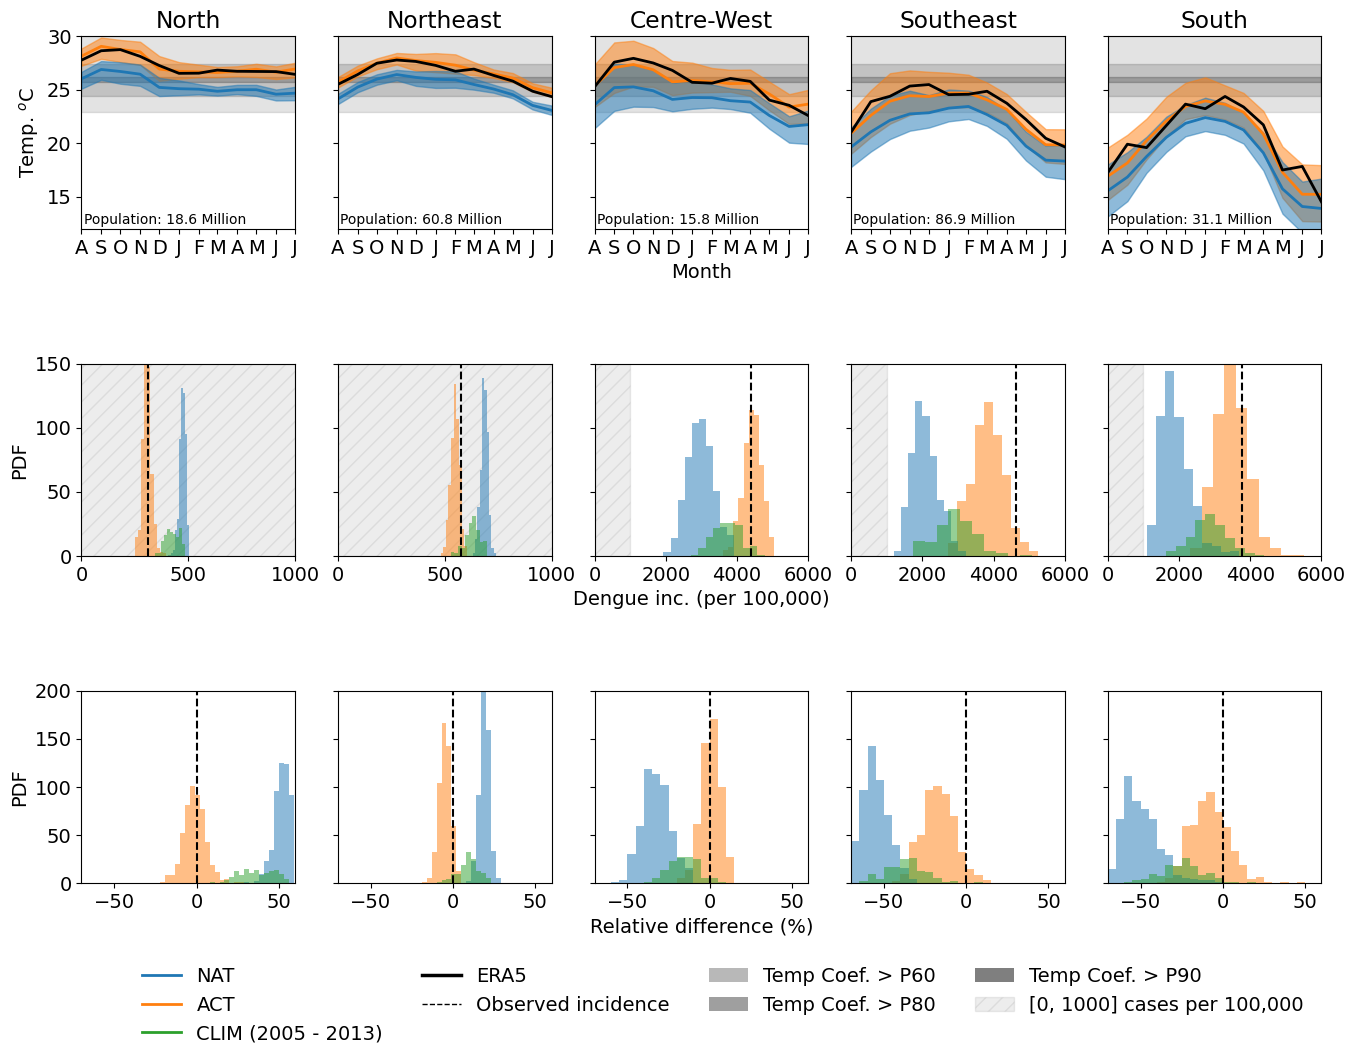

In [24]:
fig, axarr = plt.subplots(3, 5, figsize=(16, 11))
plt.subplots_adjust(wspace=0.2, hspace=0.7)

pop = pd.read_csv('data/model_input_brazil_immunity_city.csv', parse_dates=['date_first_symptoms'])
pop = pop[pop['date_first_symptoms'] == '2023-08-01']
pop = pop.groupby('region').agg({'population': 'sum'})
pop['population'] = pop['population'] / 1e6


# Temperature plots
ext = pd.read_csv('data/ext_temp_average_region.csv', parse_dates=['date_first_symptoms']).rename({'date_first_symptoms': 'time', 'mean_2m_air_temp_degree1': 'tas'}, axis=1)
nat = pd.read_csv('data/nat_temp_average_region.csv', parse_dates=['date_first_symptoms']).rename({'date_first_symptoms': 'time', 'mean_2m_air_temp_degree1': 'tas'}, axis=1)

obs = pd.read_csv('data/model_input_brazil_immunity_city.csv', parse_dates=['date_first_symptoms'])
obs = obs.groupby(['region', 'date_first_symptoms']).mean(numeric_only=True).reset_index()

ext['time'] = ext['time'].apply(lambda x: pd.to_datetime(x.strftime('%Y-%m-01')))
nat['time'] = nat['time'].apply(lambda x: pd.to_datetime(x.strftime('%Y-%m-01')))

regions = ['North', 'Northeast', 'Middle-West', 'Southeast', 'South']

ext_temp = pd.read_csv('data/ext_temp.csv')
nat_temp = pd.read_csv('data/nat_temp.csv')

obs_temp = pd.read_csv('data/model_input_brazil_immunity_city.csv', parse_dates=['date_first_symptoms'])
obs_temp = obs_temp[(obs_temp['date_first_symptoms'] >= '2023-08-01') & (obs_temp['date_first_symptoms'] <= '2024-07-31')]

obs_temp = obs_temp.groupby('region').apply(lambda x: (x['mean_2m_air_temp_degree1'] * x['population']).sum() / x['population'].sum())
obs_temp = obs_temp.reset_index().rename(columns={0: 'mean_2m_air_temp_degree1'})


# First row - Temperature
for i, region in enumerate(regions):
    ext_subset = ext[ext['region'] == region]
    nat_subset = nat[nat['region'] == region]

    ext_quantiles = ext_subset.groupby('time').quantile([0.025, 0.5, 0.975], numeric_only=True).reset_index()
    nat_quantiles = nat_subset.groupby('time').quantile([0.025, 0.5, 0.975], numeric_only=True).reset_index()

    ax = axarr[0, i]

    spans = [
        [0.6, 22.9, 30, '#737373'],
        [0.8, 24.4, 27.4, '#404040'],
        [0.9, 25.7, 26.2, '#000000']
    ]

    for span in spans:
        ax.axhspan(span[1], span[2], color=span[3], alpha=0.2)

    ax.fill_between(
        ext_quantiles[ext_quantiles['level_1'] == 0.5]['time'],
        ext_quantiles[ext_quantiles['level_1'] == 0.025]['tas'],
        ext_quantiles[ext_quantiles['level_1'] == 0.975]['tas'],
        color='C1', alpha=0.5
    )
    ax.plot(
        ext_quantiles[ext_quantiles['level_1'] == 0.5]['time'], 
        ext_quantiles[ext_quantiles['level_1'] == 0.5]['tas'],
        color='C1', lw=2
    )

    ax.fill_between(
        nat_quantiles[nat_quantiles['level_1'] == 0.5]['time'],
        nat_quantiles[nat_quantiles['level_1'] == 0.025]['tas'],
        nat_quantiles[nat_quantiles['level_1'] == 0.975]['tas'],
        color='C0', alpha=0.5
    )
    ax.plot(
        nat_quantiles[nat_quantiles['level_1'] == 0.5]['time'], 
        nat_quantiles[nat_quantiles['level_1'] == 0.5]['tas'],
        color='C0', lw=2
    )

    ax.plot(
        obs[obs['region'] == region]['date_first_symptoms'],
        obs[obs['region'] == region]['mean_2m_air_temp_degree1'],
        color='k', lw=2
    )

    ax.set_xlim(pd.to_datetime('2023-08-01'), pd.to_datetime('2024-07-31'))
    ax.set_xticks(
        pd.date_range(ext_subset['time'].min(), ext_subset['time'].max(), freq='4MS')
    )
    ax.set_xticklabels(
        pd.date_range(ext_subset['time'].min(), ext_subset['time'].max(), freq='4MS').strftime('%m/%y')
    )

    ax.set_title(region) if region != 'Middle-West' else ax.set_title('Centre-West')
    ax.set_xlim(pd.to_datetime('2023-08-01'), pd.to_datetime('2024-07-01'))
    ax.set_xticks(pd.date_range('2023-08-01', '2024-07-31', freq='MS'))
    ax.set_xticklabels(list('ASONDJFMAMJJ'))
    if i == 2:
        ax.set_xlabel('Month')
    ax.set_ylim([12, 30])
    ax.text(0.01, 0.01, f"Population: {pop.loc[region, 'population']:.1f} Million", transform=ax.transAxes, fontsize=10, verticalalignment='bottom')


# Add dengue incidence plots
ext = pd.read_csv('data/all_brazil-bs_dengue_ensemble_predictions.csv', parse_dates=['date_first_symptoms'])
nat = pd.read_csv('data/nat_brazil-bs_dengue_ensemble_predictions.csv', parse_dates=['date_first_symptoms'])
act = pd.read_csv('data/dengue_regional_aggregation.csv', parse_dates=['date_first_symptoms'])
hst = pd.read_csv('data/hist_brazil-bs_dengue_ensemble_predictions.csv', parse_dates=['date_first_symptoms'])

hst['year'] = hst['date_first_symptoms'].apply(lambda x: x.year + 1 if x.month >= 8 else x.year)

ext = ext[ext['region'].isin(regions)]
nat = nat[nat['region'].isin(regions)]
hst = hst[hst['region'].isin(regions) & (hst['year'] < 2014)]
act = act[act['region'].isin(regions) & (act['date_first_symptoms'] >= '2023-08-01') & (act['date_first_symptoms'] <= '2024-07-01')]

ext['predicted_cases'] = ext['predicted_incidence'] * ext['total_population'] / 1e5
nat['predicted_cases'] = nat['predicted_incidence'] * nat['total_population'] / 1e5
act['actual_cases'] = act['actual_regional_incidence'] * act['total_population'] / 1e5
hst['predicted_cases'] = hst['predicted_incidence'] * hst['total_population'] / 1e5

ext = ext.groupby(['region', 'file_number']).agg({'predicted_cases': 'sum', 'total_population': 'mean'}).reset_index()
nat = nat.groupby(['region', 'file_number']).agg({'predicted_cases': 'sum', 'total_population': 'mean'}).reset_index()
act = act.groupby(['region']).agg({'total_population': 'mean', 'actual_cases': 'sum'}).reset_index()
hst = hst.groupby(['region', 'year', 'file_number']).agg({'predicted_cases': 'sum', 'total_population': 'mean'}).reset_index()

ext['predicted_incidence'] = 1e5 * ext['predicted_cases'] / ext['total_population']
nat['predicted_incidence'] = 1e5 * nat['predicted_cases'] / nat['total_population']
act['actual_incidence'] = 1e5 * act['actual_cases'] / act['total_population']
hst['predicted_incidence'] = 1e5 * hst['predicted_cases'] / hst['total_population']

nat[nat['region'] == 'South'] = nat[(nat['region'] == 'South') & (nat['predicted_incidence'] <= 4000)]

# print(
#     (ext.groupby('file_number')['predicted_incidence'].sum().mean() - nat.groupby('file_number')['predicted_incidence'].sum().mean()) / act['actual_incidence'].sum()
# )

# Third row - Dengue incidence histogram (normalized)
for i, (ax, region) in enumerate(zip(axarr[2], regions)):    
    act_region = act[act['region'] == region]['actual_incidence'].values[0]

    bins1 = np.arange(-70, 60, 3)
    bins2 = np.arange(-70, 60, 5)
    if region in ['North', 'Northeast']:
        bins = bins1
    else:
        bins = bins2

    ax.hist(100 * (ext[ext['region'] == region]['predicted_incidence'] - act_region) / act_region, color='C1', alpha=0.5, bins=bins)
    ax.hist(100 * (nat[nat['region'] == region]['predicted_incidence'] - act_region) / act_region, color='C0', alpha=0.5, bins=bins)
    ax.hist(100 * (hst[hst['region'] == region]['predicted_incidence'] - act_region) / act_region, color='C2', alpha=0.5, bins=bins)

    np.random.seed(42)
    bootstrap_ext = np.random.choice(ext[ext['region'] == region]['predicted_incidence'], size=(1000, 525), replace=True).mean(axis=1)
    bootstrap_nat = np.random.choice(nat[nat['region'] == region]['predicted_incidence'], size=(1000, 525), replace=True).mean(axis=1)

    diff = 100 * (bootstrap_ext - bootstrap_nat) / act_region

    print(region)
    print(np.percentile(diff, 2.5), np.percentile(diff, 50), np.percentile(diff, 97.5))
    print(
        100 * (np.percentile(bootstrap_ext, 2.5) / act_region - np.percentile(bootstrap_nat, 2.5) / act_region),
        100 * (np.percentile(bootstrap_ext, 50) / act_region - np.percentile(bootstrap_nat, 50) / act_region),
        100 * (np.percentile(bootstrap_ext, 97.5) / act_region - np.percentile(bootstrap_nat, 97.5) / act_region)
    )

    # print((ext[ext['region'] == region]['predicted_incidence'] / act_region).mean() - (nat[nat['region'] == region]['predicted_incidence'] / act_region).mean())
    # print((ext[ext['region'] == region]['predicted_incidence'] / act_region).mean() - (hst[hst['region'] == region]['predicted_incidence'] / act_region).mean())

    ax.axvline(0, color='k', ls='--')
    if i == 2:
        ax.set_xlabel('Relative difference (%)')
    ax.set_ylim([0, 200])
    ax.set_xlim([-70, 60])

# Second row - Dengue incidence histogram (absolute)
for i, (ax, region) in enumerate(zip(axarr[1], regions)):    
    act_region = act[act['region'] == region]['actual_incidence'].values[0]

    if region in ['North', 'Northeast']:
        ax.set_xlim([0, 1000])
    else:
        ax.set_xlim([0, 6000])

    ax.axvspan(0, 1000, color='k', alpha=0.07, hatch='//')
    #ax.fill_between([0,1000],[0,150], color="none", hatch="/", edgecolor="k", linewidth=0.0)

    bins1 = np.arange(0, 6000, 5)
    bins2 = np.arange(0, 6000, 10)
    
    if region in ['North', 'Northeast']:
        bins = bins1
    else:
        bins = bins2

    ax.hist(ext[ext['region'] == region]['predicted_incidence'], color='C1', alpha=0.5)
    ax.hist(nat[nat['region'] == region]['predicted_incidence'], color='C0', alpha=0.5)
    ax.hist(hst[hst['region'] == region]['predicted_incidence'], color='C2', alpha=0.5)

    ax.axvline(act_region, color='k', ls='--')
    if i == 2:
        ax.set_xlabel('Dengue inc. (per 100,000)')
    ax.set_ylim([0, 150])
    
    #ax.set_xticks([0, 100, 200, 300, 400, 500])

axarr[0, 0].set_ylabel(r'Temp. $^o$C')
axarr[1, 0].set_ylabel('PDF')
axarr[2, 0].set_ylabel('PDF')

for i in range(1,5):
    axarr[0, i].set_yticklabels([])
    axarr[1, i].set_yticklabels([])
    axarr[2, i].set_yticklabels([])

legend_elements = []

legend_elements.append(Line2D([0], [0], color='C0', lw=2, label='NAT'))
legend_elements.append(Line2D([0], [0], color='C1', lw=2, label='ACT'))
legend_elements.append(Line2D([0], [0], color='C2', lw=2, label='CLIM (2005 - 2013)'))
legend_elements.append(Line2D([0], [0], color='k', lw=2.5, label='ERA5'))
legend_elements.append(Line2D([0], [0], color='k', ls='--', lw=1, label='Observed incidence'))
legend_elements.append(Patch(facecolor='#737373', alpha=0.5, label='Temp Coef. > P60'))
legend_elements.append(Patch(facecolor='#404040', alpha=0.5, label='Temp Coef. > P80'))
legend_elements.append(Patch(facecolor='#000000', alpha=0.5, label='Temp Coef. > P90'))
legend_elements.append(Patch(color='k', hatch='//', alpha=0.07, label='[0, 1000] cases per 100,000'))

# Place legend on the figure level or first axis
fig.legend(handles=legend_elements, frameon=False, ncol=4, bbox_to_anchor=(0.9, 0.05))
plt.savefig('img/dengue_temperature_analysis.pdf', dpi=300, bbox_inches='tight')